<a href="https://colab.research.google.com/github/contreras-juan/Material-Ciencia-de-Datos/blob/main/Deep_Learning/Ejercicios/Soluciones/01_Taller_Fundamentos_Redes_Neuronales_Solucion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1 style="color: #FECB05; text-align: center;">Solución — Taller práctico: Fundamentos de redes neuronales</h1>


<h2 style="color: #007ACC;">Autores</h2>

- [Juan Felipe Contreras Alcívar](https://www.linkedin.com/in/juanf-contreras/)

> Esta es una **solución de referencia** del taller [`01_Taller_Fundamentos_Redes_Neuronales.ipynb`](../01_Taller_Fundamentos_Redes_Neuronales.ipynb).
> Los resultados numéricos pueden variar ligeramente según la versión de TensorFlow y la semilla del hardware.


---


<h2 style="color: #007ACC;">Tabla de contenido</h2>

- [Instalación e importaciones](#importaciones)
- [Ejercicio 1. Funciones de activación](#ejercicio-1)
- [Ejercicio 2. Optimizadores](#ejercicio-2)
- [Ejercicio 3. Entrenamiento de una red neuronal](#ejercicio-3)
- [Ejercicio 4. Curvas de entrenamiento](#ejercicio-4)
- [Ejercicio 5. Callbacks](#ejercicio-5)
- [Ejercicio integrador](#ejercicio-integrador)


---

<a id="importaciones"></a>
<h2 style="color: #007ACC;">Instalación e importaciones</h2>

Ejecuta primero la celda de instalación (útil en Google Colab) y luego la de importaciones.


In [ ]:
# Instalación de librerías necesarias para esta sesión
# (útil en Google Colab o en un entorno nuevo)
%pip install -q numpy pandas matplotlib scikit-learn tensorflow


In [31]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import load_wine, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import SGD, RMSprop, Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, LearningRateScheduler, ModelCheckpoint
from tensorflow.keras.regularizers import L2

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


---

<a id="ejercicio-1"></a>
<h2 style="color: #007ACC;">Ejercicio 1. Funciones de activación</h2>


<h3 style="color: #003366;">1.1 Implementación</h3>


In [32]:
def relu(x):
    return np.maximum(0, x)

def tanh(x):
    return np.tanh(x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def softmax(z):
    # Versión numéricamente estable para un vector 1D
    z = np.asarray(z, dtype=float)
    z_shift = z - np.max(z)
    exp_z = np.exp(z_shift)
    return exp_z / np.sum(exp_z)

x = np.array([-2.0, -1.0, 0.0, 1.0, 2.0])
print("ReLU:", relu(x))
print("tanh:", tanh(x))
print("sigmoid:", sigmoid(x))
print("softmax:", softmax(np.array([1.0, 2.0, 3.0])))
print("Suma softmax:", softmax(np.array([1.0, 2.0, 3.0])).sum())

ReLU: [0. 0. 0. 1. 2.]
tanh: [-0.96402758 -0.76159416  0.          0.76159416  0.96402758]
sigmoid: [0.11920292 0.26894142 0.5        0.73105858 0.88079708]
softmax: [0.09003057 0.24472847 0.66524096]
Suma softmax: 0.9999999999999999


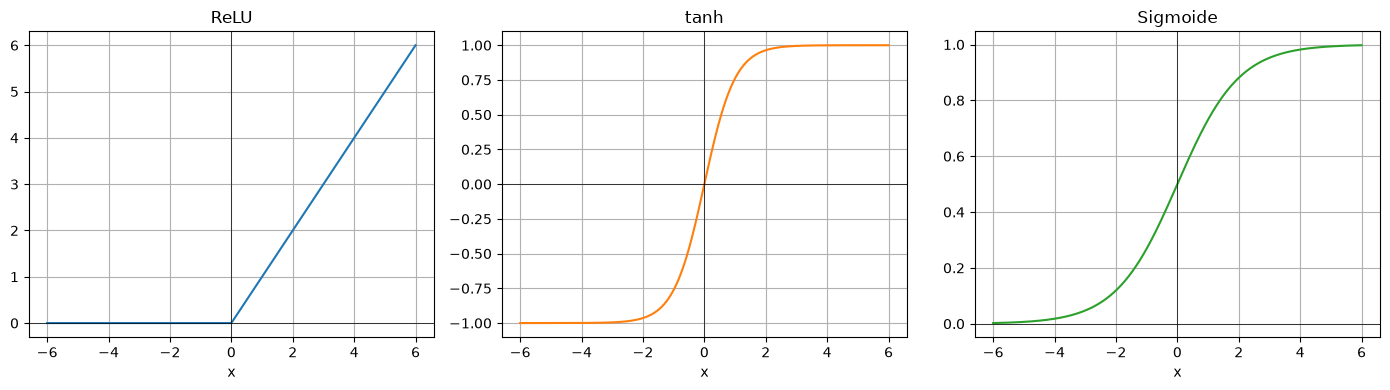

In [33]:
x_plot = np.linspace(-6, 6, 300)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(x_plot, relu(x_plot), color="C0")
axes[0].set_title("ReLU")
axes[0].grid(True)

axes[1].plot(x_plot, tanh(x_plot), color="C1")
axes[1].set_title("tanh")
axes[1].grid(True)

axes[2].plot(x_plot, sigmoid(x_plot), color="C2")
axes[2].set_title("Sigmoide")
axes[2].grid(True)

for ax in axes:
    ax.axhline(0, color="black", linewidth=0.5)
    ax.axvline(0, color="black", linewidth=0.5)
    ax.set_xlabel("x")

plt.tight_layout()
plt.show()

<h3 style="color: #003366;">1.2 Preguntas de reflexión — respuestas</h3>

1. **Activaciones lineales:** la composición de transformaciones afines es otra transformación afín. Sin no linealidad, varias capas `Dense` se colapsan en una sola capa lineal (o logística si la salida es sigmoide/softmax). Por eso las activaciones no lineales son esenciales para aprender patrones complejos.

2. **Softmax:** se usa en la **capa de salida** de clasificación **multiclase**, porque convierte logits en un vector de probabilidades que suma 1.

3. **ReLU vs sigmoide:** ReLU es más barata de calcular, mitiga mejor la saturación/vanishing gradients en capas ocultas profundas y favorece representaciones dispersas (muchas activaciones en cero).

4. **Teorema de Aproximación Universal:** garantiza que una red con una capa oculta y activación no lineal adecuada *puede* aproximar cualquier función continua en un compacto con error arbitrario. **No** garantiza que el entrenamiento encuentre esos pesos, ni da un tamaño práctico de red, ni evita sobreajuste.


---

<a id="ejercicio-2"></a>
<h2 style="color: #007ACC;">Ejercicio 2. Optimizadores</h2>


<h3 style="color: #003366;">2.1 Descenso de gradiente unidimensional</h3>

Los puntos críticos cumplen $f'(x)=x^{2}(4x-9)=0$, es decir $x=0$ y $x=9/4=2.25$. El **mínimo global** está en $x=2.25$.

Comparamos tres escenarios en una grilla:

1. $x_0=-0.5$, $\eta=0.01$: el método **se estanca** en $x=0$ porque $f'(0)=0$.
2. $x_0=0.5$, $\eta=0.01$: converge al mínimo global.
3. $x_0=0.5$, $\eta=0.05$: converge al mínimo global con pasos más grandes.


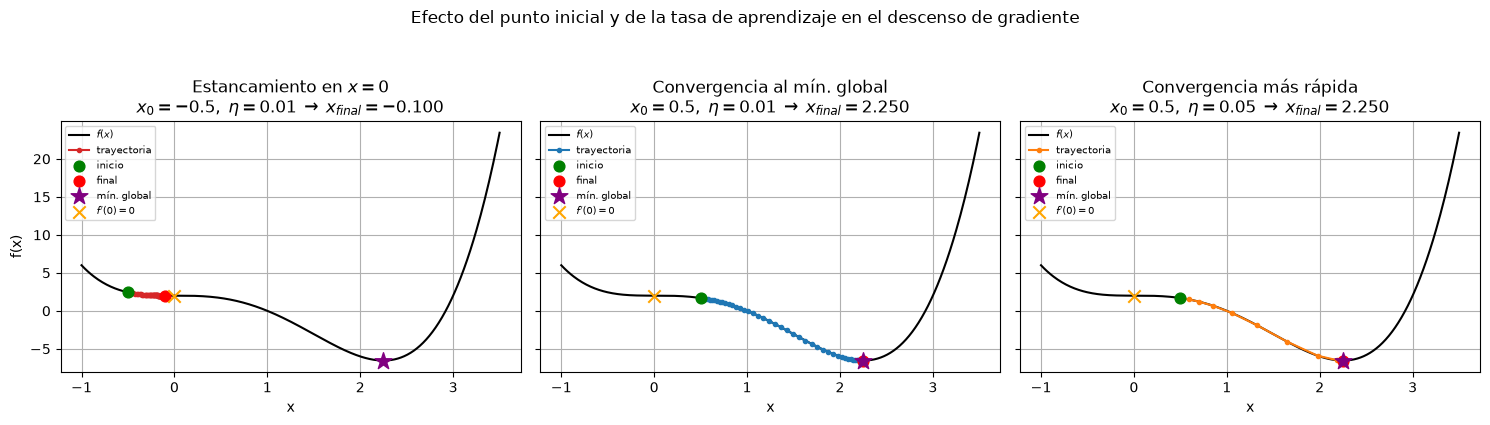

Panel 1: con x0=-0.5 el método se estanca en x=0 porque f'(0)=0.
Paneles 2 y 3: con x0=0.5 se alcanza el mínimo global x=2.25; eta mayor llega con menos pasos efectivos.


In [34]:
def f(x):
    return x**4 - 3 * x**3 + 2

def grad_f(x):
    return 4 * x**3 - 9 * x**2

def gradient_descent(x0, lr, n_iters):
    path = [x0]
    x = float(x0)
    for _ in range(n_iters):
        x = x - lr * grad_f(x)
        path.append(x)
    return path

x_global_min = 9 / 4
x_critical = 0.0
n_iters = 80

# Tres escenarios: estancamiento vs convergencia al mínimo global
escenarios = [
    {"x0": -0.5, "lr": 0.01, "color": "C3", "titulo": "Estancamiento en $x=0$"},
    {"x0": 0.5, "lr": 0.01, "color": "C0", "titulo": "Convergencia al mín. global"},
    {"x0": 0.5, "lr": 0.05, "color": "C1", "titulo": "Convergencia más rápida"},
]

x_values = np.linspace(-1.0, 3.5, 400)
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, esc in zip(axes, escenarios):
    path = gradient_descent(x0=esc["x0"], lr=esc["lr"], n_iters=n_iters)
    ax.plot(x_values, f(x_values), color="black", label=r"$f(x)$")
    ax.plot(path, [f(x) for x in path], "o-", markersize=3, color=esc["color"], label="trayectoria")
    ax.scatter(path[0], f(path[0]), color="green", s=60, zorder=5, label="inicio")
    ax.scatter(path[-1], f(path[-1]), color="red", s=60, zorder=5, label="final")
    ax.scatter(x_global_min, f(x_global_min), marker="*", color="purple", s=160, zorder=6, label="mín. global")
    ax.scatter(x_critical, f(x_critical), marker="x", color="orange", s=80, zorder=6, label=r"$f'(0)=0$")
    ax.set_title(
        esc["titulo"]
        + "\n"
        + rf"$x_0={esc['x0']},\;\eta={esc['lr']}\;\rightarrow\;x_{{final}}={path[-1]:.3f}$"
    )
    ax.set_xlabel("x")
    ax.grid(True)
    ax.legend(fontsize=7)

axes[0].set_ylabel("f(x)")
fig.suptitle("Efecto del punto inicial y de la tasa de aprendizaje en el descenso de gradiente", y=1.05)
plt.tight_layout()
plt.show()

print("Panel 1: con x0=-0.5 el método se estanca en x=0 porque f'(0)=0.")
print("Paneles 2 y 3: con x0=0.5 se alcanza el mínimo global x=2.25; eta mayor llega con menos pasos efectivos.")


<h3 style="color: #003366;">2.2 Comparación de optimizadores</h3>


In [35]:
X_moons, y_moons = make_moons(n_samples=1000, noise=0.25, random_state=SEED)
X_moons = StandardScaler().fit_transform(X_moons)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_moons, y_moons, test_size=0.2, random_state=SEED, stratify=y_moons
)

def build_binary_model():
    return Sequential([
        Dense(16, activation="relu", input_shape=(2,)),
        Dense(8, activation="relu"),
        Dense(1, activation="sigmoid"),
    ])

optimizers = {
    "SGD": SGD(learning_rate=0.05),
    "RMSprop": RMSprop(learning_rate=0.01),
    "Adam": Adam(learning_rate=0.01),
}

histories = {}

for name, opt in optimizers.items():
    tf.random.set_seed(SEED)
    model = build_binary_model()
    model.compile(optimizer=opt, loss="binary_crossentropy", metrics=["accuracy"])
    history = model.fit(
        X_tr, y_tr,
        validation_split=0.2,
        epochs=40,
        batch_size=32,
        verbose=0,
    )
    histories[name] = history
    test_loss, test_acc = model.evaluate(X_te, y_te, verbose=0)
    print(f"{name:8s} | test loss={test_loss:.4f} | test acc={test_acc:.4f}")

/home/juanf/Projects/Material-Ciencia-de-Datos/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


SGD      | test loss=0.1989 | test acc=0.9150
RMSprop  | test loss=0.0740 | test acc=0.9800
Adam     | test loss=0.0893 | test acc=0.9800


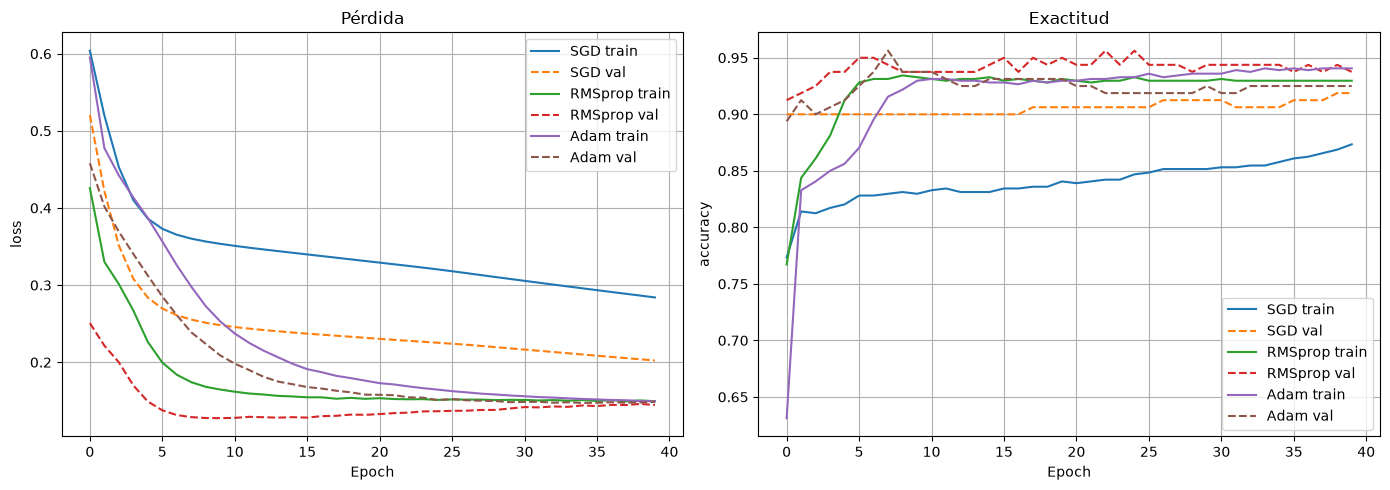

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, history in histories.items():
    axes[0].plot(history.history["loss"], label=f"{name} train")
    axes[0].plot(history.history["val_loss"], "--", label=f"{name} val")
    axes[1].plot(history.history["accuracy"], label=f"{name} train")
    axes[1].plot(history.history["val_accuracy"], "--", label=f"{name} val")

axes[0].set_title("Pérdida")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("loss")
axes[0].legend()
axes[0].grid(True)

axes[1].set_title("Exactitud")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

**Respuesta (típica):** Adam y RMSprop suelen converger más rápido y con curvas más suaves que SGD. SGD, incluso con una tasa relativamente alta, tiende a bajar más lento y puede mostrar más oscilaciones en `val_loss`/`val_accuracy`, porque no adapta la tasa por parámetro ni acumula momentum adaptativo como Adam.


---

<a id="ejercicio-3"></a>
<h2 style="color: #007ACC;">Ejercicio 3. Entrenamiento de una red neuronal</h2>


<h3 style="color: #003366;">3.1 Clasificación con Wine</h3>


/home/juanf/Projects/Material-Ciencia-de-Datos/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test loss: 0.0355
Test accuracy: 1.0000


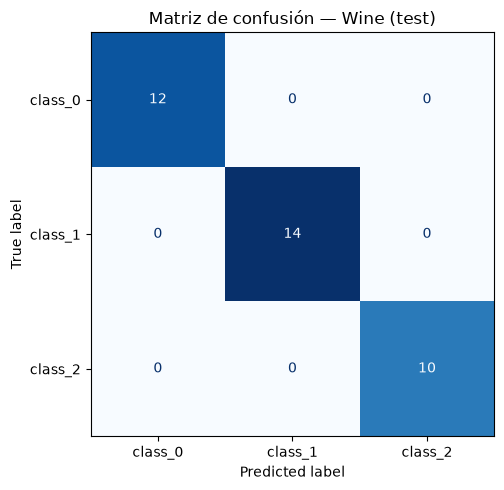


Classification report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



In [37]:
wine = load_wine()
X = wine.data
y = wine.target.reshape(-1, 1)
class_names = wine.target_names

try:
    encoder = OneHotEncoder(sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(sparse=False)

y_oh = encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_oh, test_size=0.2, random_state=SEED, stratify=y_oh
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

tf.random.set_seed(SEED)
model_wine = Sequential([
    Dense(16, activation="relu", input_shape=(X_train_s.shape[1],)),
    Dense(8, activation="relu"),
    Dense(3, activation="softmax"),
])

model_wine.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history_wine = model_wine.fit(
    X_train_s, y_train,
    epochs=80,
    batch_size=16,
    validation_split=0.2,
    verbose=0,
)

test_loss, test_acc = model_wine.evaluate(X_test_s, y_test, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

y_pred = np.argmax(model_wine.predict(X_test_s, verbose=0), axis=1)
y_true = np.argmax(y_test, axis=1)

from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(
    ax=ax, cmap="Blues", colorbar=False
)
ax.set_title("Matriz de confusión — Wine (test)")
plt.tight_layout()
plt.show()

print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=class_names))

<h3 style="color: #003366;">3.2 Preguntas — respuestas</h3>

1. Hay **3 clases mutuamente excluyentes**. Softmax produce una distribución de probabilidad conjunta (suma 1). Sigmoide independiente por neurona sería más propia de clasificación **multi-etiqueta**.

2. Sin estandarizar, variables con escalas muy distintas dominan el gradiente. El entrenamiento se vuelve más lento o inestable y la convergencia empeora.

3. En este dataset pequeño y bien separado, la exactitud en test suele ser alta. Si alguna clase concentra más errores, suele ser por solapamiento de características; revisa la matriz de confusión impresa arriba.


---

<a id="ejercicio-4"></a>
<h2 style="color: #007ACC;">Ejercicio 4. Curvas de entrenamiento</h2>


<h3 style="color: #003366;">4.1 Modelo propenso a sobreajuste</h3>


/home/juanf/Projects/Material-Ciencia-de-Datos/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


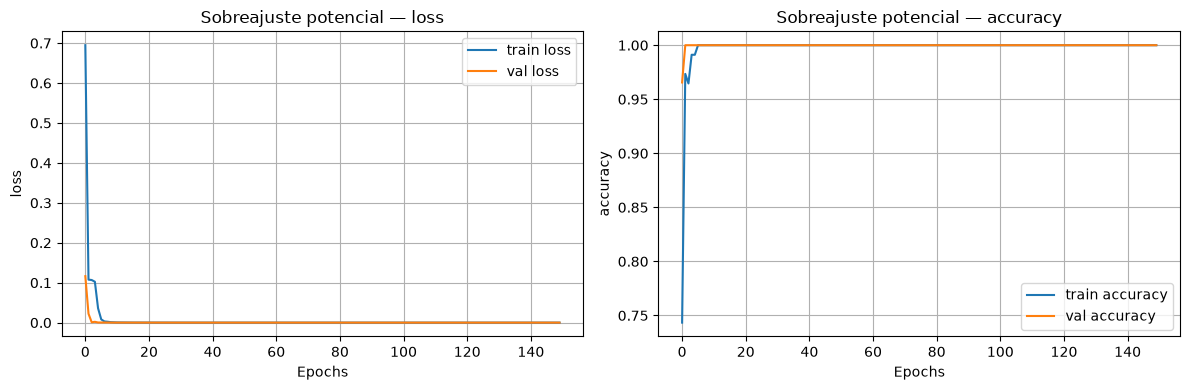

Épocas entrenadas: 150
Train acc final: 1.0
Val acc final: 1.0


In [38]:
def plot_training_curves(history, metrics=("loss", "accuracy"), title_prefix=""):
    history_dict = history.history if hasattr(history, "history") else history
    n = len(metrics)
    plt.figure(figsize=(6 * n, 4))
    for i, metric in enumerate(metrics):
        plt.subplot(1, n, i + 1)
        plt.plot(history_dict[metric], label=f"train {metric}")
        plt.plot(history_dict[f"val_{metric}"], label=f"val {metric}")
        plt.xlabel("Epochs")
        plt.ylabel(metric)
        plt.title(f"{title_prefix}{metric}")
        plt.legend()
        plt.grid(True)
    plt.tight_layout()
    plt.show()

tf.random.set_seed(SEED)
model_over = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_s.shape[1],)),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(3, activation="softmax"),
])

model_over.compile(optimizer=Adam(learning_rate=0.01), loss="categorical_crossentropy", metrics=["accuracy"])

history_over = model_over.fit(
    X_train_s, y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=16,
    verbose=0,
)

plot_training_curves(history_over, title_prefix="Sobreajuste potencial — ")
print("Épocas entrenadas:", len(history_over.history["loss"]))
print("Train acc final:", history_over.history["accuracy"][-1])
print("Val acc final:", history_over.history["val_accuracy"][-1])

<h3 style="color: #003366;">4.2 Diagnóstico y corrección</h3>

**Diagnóstico esperado:** si `train loss` sigue bajando mientras `val loss` se estanca o sube (y/o hay una brecha grande en accuracy), el patrón es de **sobreajuste**. Wine es pequeño, así que un modelo 64-64-32 con muchas épocas es un buen candidato a memorizar.

**Corrección aplicada:** red más pequeña + `Dropout` + regularización `L2`.


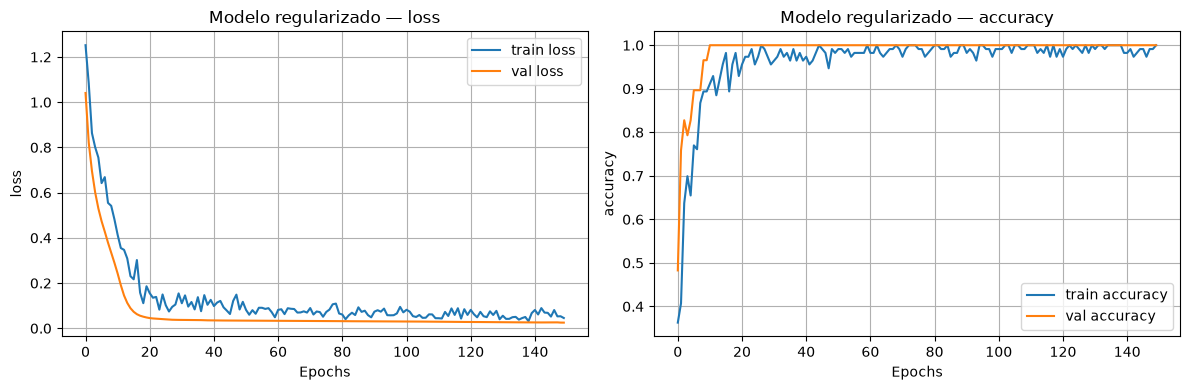

Test accuracy modelo grande: 1.0000
Test accuracy modelo regularizado: 1.0000


In [39]:
tf.random.set_seed(SEED)
model_reg = Sequential([
    Dense(16, activation="relu", input_shape=(X_train_s.shape[1],), kernel_regularizer=L2(1e-3)),
    Dropout(0.3),
    Dense(8, activation="relu", kernel_regularizer=L2(1e-3)),
    Dropout(0.2),
    Dense(3, activation="softmax"),
])

model_reg.compile(optimizer=Adam(learning_rate=0.005), loss="categorical_crossentropy", metrics=["accuracy"])

history_reg = model_reg.fit(
    X_train_s, y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=16,
    verbose=0,
)

plot_training_curves(history_reg, title_prefix="Modelo regularizado — ")

_, acc_over = model_over.evaluate(X_test_s, y_test, verbose=0)
_, acc_reg = model_reg.evaluate(X_test_s, y_test, verbose=0)
print(f"Test accuracy modelo grande: {acc_over:.4f}")
print(f"Test accuracy modelo regularizado: {acc_reg:.4f}")

**Respuesta:** la regularización suele **cerrar la brecha** train/val. Es normal sacrificar un poco de exactitud de entrenamiento a cambio de curvas más alineadas y, con suerte, mejor o similar generalización en test.


---

<a id="ejercicio-5"></a>
<h2 style="color: #007ACC;">Ejercicio 5. Callbacks</h2>


<h3 style="color: #003366;">5.1 EarlyStopping + ReduceLROnPlateau</h3>

Usamos `patience` de ReduceLR **menor** que la de EarlyStopping, para permitir bajadas de $\eta$ antes de detener el entrenamiento.



Epoch 87: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.

Epoch 94: ReduceLROnPlateau reducing learning rate to 0.0024999999441206455.

Epoch 99: ReduceLROnPlateau reducing learning rate to 0.0012499999720603228.

Epoch 104: ReduceLROnPlateau reducing learning rate to 0.0006249999860301614.

Epoch 109: ReduceLROnPlateau reducing learning rate to 0.0003124999930150807.

Epoch 114: ReduceLROnPlateau reducing learning rate to 0.00015624999650754035.

Epoch 119: ReduceLROnPlateau reducing learning rate to 7.812499825377017e-05.

Epoch 124: ReduceLROnPlateau reducing learning rate to 3.9062499126885086e-05.

Epoch 129: ReduceLROnPlateau reducing learning rate to 1.9531249563442543e-05.

Epoch 134: ReduceLROnPlateau reducing learning rate to 9.765624781721272e-06.

Epoch 139: ReduceLROnPlateau reducing learning rate to 4.882812390860636e-06.

Epoch 144: ReduceLROnPlateau reducing learning rate to 2.441406195430318e-06.

Epoch 149: ReduceLROnPlateau reducing learning rate 

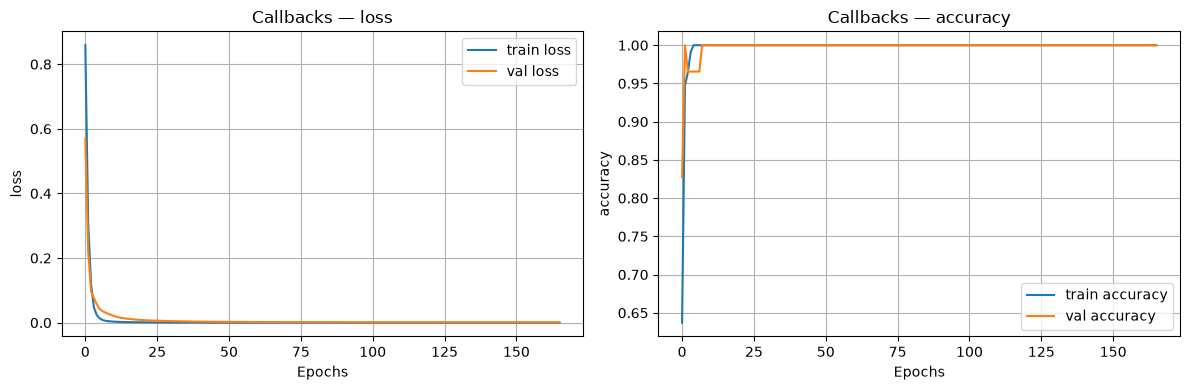

Test loss=0.0710 | Test acc=0.9722


In [40]:
tf.random.set_seed(SEED)
model_cb = Sequential([
    Dense(32, activation="relu", input_shape=(X_train_s.shape[1],)),
    Dense(16, activation="relu"),
    Dense(3, activation="softmax"),
])

model_cb.compile(optimizer=Adam(learning_rate=0.01), loss="categorical_crossentropy", metrics=["accuracy"])

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=12,
    restore_best_weights=True,
    verbose=1,
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1,
)

history_cb = model_cb.fit(
    X_train_s, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=16,
    callbacks=[early_stopping, reduce_lr],
    verbose=0,
)

n_epochs = len(history_cb.history["loss"])
print(f"Entrenamiento detenido tras {n_epochs} épocas (máximo pedido: 200).")
if "lr" in history_cb.history:
    print("LR inicial:", history_cb.history["lr"][0])
    print("LR final:", history_cb.history["lr"][-1])
else:
    print("Nota: la clave 'lr' puede no aparecer en history según la versión de Keras;")
    print("revisa los logs de ReduceLROnPlateau para ver las reducciones.")

plot_training_curves(history_cb, title_prefix="Callbacks — ")
test_loss_cb, test_acc_cb = model_cb.evaluate(X_test_s, y_test, verbose=0)
print(f"Test loss={test_loss_cb:.4f} | Test acc={test_acc_cb:.4f}")

<h3 style="color: #003366;">5.2 LearningRateScheduler (step decay)</h3>


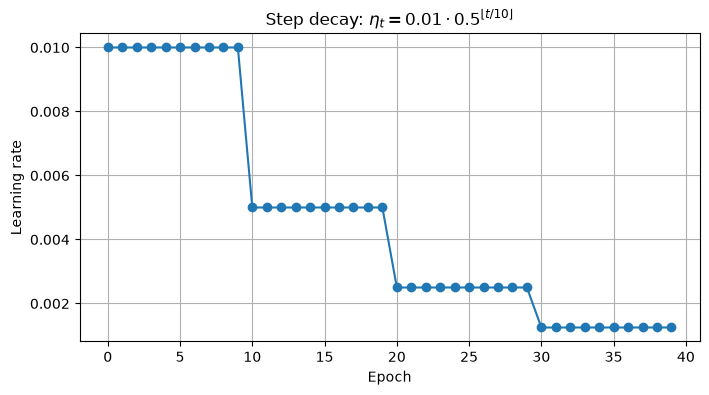

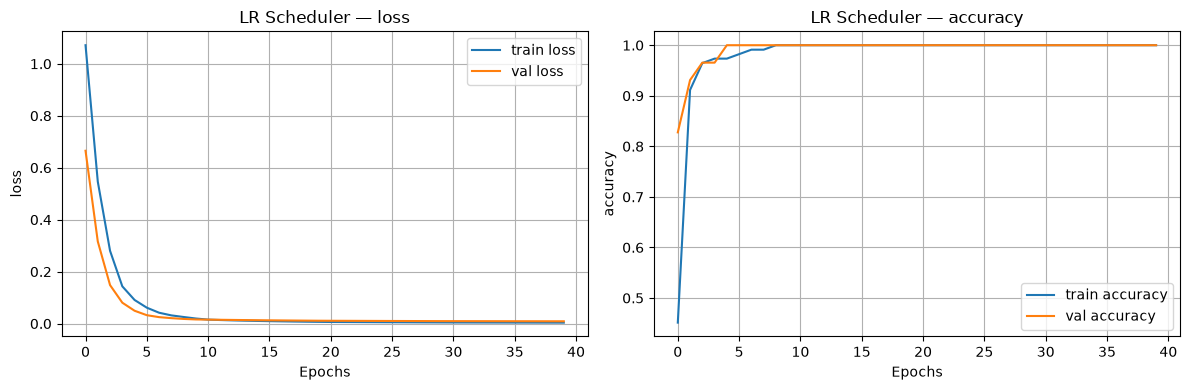

In [41]:
def lr_schedule(epoch, lr=None):
    initial_lr = 0.01
    return initial_lr * (0.5 ** (epoch // 10))

lr_scheduler = LearningRateScheduler(lr_schedule, verbose=0)

tf.random.set_seed(SEED)
model_lrs = Sequential([
    Dense(16, activation="relu", input_shape=(X_train_s.shape[1],)),
    Dense(8, activation="relu"),
    Dense(3, activation="softmax"),
])

model_lrs.compile(
    optimizer=Adam(learning_rate=0.01),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history_lrs = model_lrs.fit(
    X_train_s, y_train,
    epochs=40,
    batch_size=16,
    validation_split=0.2,
    callbacks=[lr_scheduler],
    verbose=0,
)

epochs = np.arange(40)
lrs = [lr_schedule(e) for e in epochs]

plt.figure(figsize=(8, 4))
plt.plot(epochs, lrs, "o-", color="C0")
plt.title(r"Step decay: $\eta_t = 0.01 \cdot 0.5^{\lfloor t/10 \rfloor}$")
plt.xlabel("Epoch")
plt.ylabel("Learning rate")
plt.grid(True)
plt.show()

plot_training_curves(history_lrs, title_prefix="LR Scheduler — ")

<h3 style="color: #003366;">5.3 ModelCheckpoint</h3>

Guardamos el mejor modelo en disco y lo recargamos para evaluar en test.


In [ ]:
tf.random.set_seed(SEED)
model_ckpt = Sequential([
    Dense(32, activation="relu", input_shape=(X_train_s.shape[1],)),
    Dense(16, activation="relu"),
    Dense(3, activation="softmax"),
])
model_ckpt.compile(optimizer=Adam(learning_rate=0.01), loss="categorical_crossentropy", metrics=["accuracy"])

ckpt_path = "mejor_modelo_wine_taller.keras"
callbacks_ckpt = [
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=0),
    EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True, verbose=0),
    ModelCheckpoint(filepath=ckpt_path, monitor="val_loss", save_best_only=True, verbose=0),
]

history_ckpt = model_ckpt.fit(
    X_train_s, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=16,
    callbacks=callbacks_ckpt,
    verbose=0,
)

loaded = tf.keras.models.load_model(ckpt_path)
loss_mem, acc_mem = model_ckpt.evaluate(X_test_s, y_test, verbose=0)
loss_disk, acc_disk = loaded.evaluate(X_test_s, y_test, verbose=0)

print(f"Épocas efectivas: {len(history_ckpt.history['loss'])}")
print(f"Modelo en memoria | test loss={loss_mem:.4f} | test acc={acc_mem:.4f}")
print(f"Modelo cargado    | test loss={loss_disk:.4f} | test acc={acc_disk:.4f}")
plot_training_curves(history_ckpt, title_prefix="ModelCheckpoint — ")


---

<a id="ejercicio-integrador"></a>
<h2 style="color: #007ACC;">Ejercicio integrador</h2>

Comparamos una arquitectura **simple** frente a una **más profunda/ancha** sobre Wine, ambas con Adam + EarlyStopping + ReduceLROnPlateau.


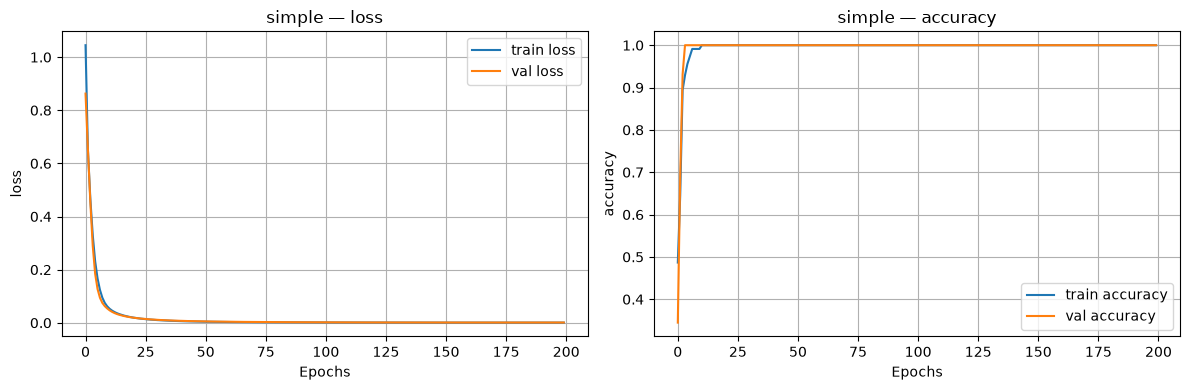

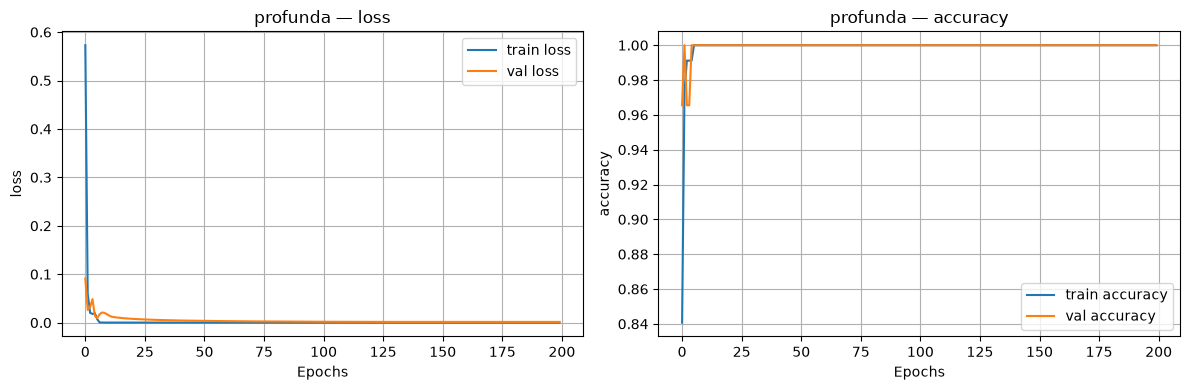

arquitectura  epochs_efectivas  train_acc_final  val_acc_final  test_acc  test_loss  gap_train_val
      simple               200              1.0            1.0       1.0     0.0042            0.0
    profunda               200              1.0            1.0       1.0     0.0050            0.0

Ganador sugerido: simple
Conclusión: preferimos la arquitectura con mejor desempeño en test y menor evidencia de sobreajuste (gap train/val = 0.0). En datasets pequeños como Wine, un modelo simple a menudo generaliza igual o mejor que uno profundo si este último memoriza el entrenamiento.


In [42]:
def make_callbacks(checkpoint_path=None):
    cbs = [
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=6, min_lr=1e-6, verbose=0),
        EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True, verbose=0),
    ]
    if checkpoint_path is not None:
        cbs.append(ModelCheckpoint(filepath=checkpoint_path, monitor="val_loss", save_best_only=True, verbose=0))
    return cbs

architectures = {
    "simple": lambda: Sequential([
        Dense(8, activation="relu", input_shape=(X_train_s.shape[1],)),
        Dense(3, activation="softmax"),
    ]),
    "profunda": lambda: Sequential([
        Dense(64, activation="relu", input_shape=(X_train_s.shape[1],)),
        Dense(32, activation="relu"),
        Dense(16, activation="relu"),
        Dense(3, activation="softmax"),
    ]),
}

results = []
histories_int = {}

for name, builder in architectures.items():
    tf.random.set_seed(SEED)
    model = builder()
    model.compile(optimizer=Adam(learning_rate=0.01), loss="categorical_crossentropy", metrics=["accuracy"])

    history = model.fit(
        X_train_s, y_train,
        validation_split=0.2,
        epochs=200,
        batch_size=16,
        callbacks=make_callbacks(checkpoint_path=f"mejor_{name}.keras"),
        verbose=0,
    )
    histories_int[name] = history

    test_loss, test_acc = model.evaluate(X_test_s, y_test, verbose=0)
    train_acc = history.history["accuracy"][-1]
    val_acc = history.history["val_accuracy"][-1]
    n_epochs = len(history.history["loss"])

    results.append({
        "arquitectura": name,
        "epochs_efectivas": n_epochs,
        "train_acc_final": round(train_acc, 4),
        "val_acc_final": round(val_acc, 4),
        "test_acc": round(test_acc, 4),
        "test_loss": round(test_loss, 4),
        "gap_train_val": round(train_acc - val_acc, 4),
    })

    plot_training_curves(history, title_prefix=f"{name} — ")

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

best = df_results.sort_values(["test_acc", "gap_train_val"], ascending=[False, True]).iloc[0]
print("\nGanador sugerido:", best["arquitectura"])
print(
    "Conclusión: preferimos la arquitectura con mejor desempeño en test y menor evidencia de sobreajuste "
    f"(gap train/val = {best['gap_train_val']}). En datasets pequeños como Wine, un modelo simple a menudo "
    "generaliza igual o mejor que uno profundo si este último memoriza el entrenamiento."
)
